# **Part One: Accord Classification** #



---

## Introduction 

The first part of our problem statement is to **predict the main accords of a fragrance based on its notes**. This is a multi-label classification problem, where an instance belongs to multiple classes at the same time. Our final approach is to use supervised learning with One-vs-Rest (OVR) Classifier  with XGBoost (Extreme Gradient Boosting) model as a parameter and MLSMOTE (Multi-Label Synthetic Minority Over-sampling Technique) to address accord class imbalance in our dataset.

### Tasks 

- Prepare Data
- Train Model
- Make Predictions
- Model Evaluations
- Individual Fragrance Predictions


## Prepare Data 

We access our cleaned dataset from ``./Data/fragrance_cleaned.csv``. This dataset contains 43,733 unique fragrance entries, with information about their Name, Rating value, Gender, Top Notes, Middle Notes, Base Notes, and Accords. Each fragrance's values regarding Gender, Notes, and Accords are set up as a numerical binary vector using Multi-hot encoding. This data is derived from the Kaggle Dataset, *Fragrantica.com Fragrance Dataset*, by user miufana1.

#### Load the cleaned dataset

In [1]:
import pandas as pd

path = "./Data/fragrance_cleaned.csv"
df = pd.read_csv(path) # Read the data and convert it to a dataframe

df.head()

,Name,Rating Value,gender_unisex,gender_women,gender_men,Rating Count,top_note_aldehydes,top_note_apple,top_note_bergamot,top_note_black currant,...,accord_rose,accord_smoky,accord_soft spicy,accord_tobacco,accord_tropical,accord_tuberose,accord_vanilla,accord_violet,accord_white floral,accord_yellow floral
0,9am Afnan,0.6825,0,1,0,0.005794,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,9am Dive Afnan,0.8225,1,0,0,0.028168,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,9am pour Femme Afnan,0.7500,0,1,0,0.002244,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,9pm Afnan,0.8750,0,0,1,0.229896,0,1,1,0,...,0,0,0,0,0,0,1,0,0,0
4,9pm pour Femme Afnan,0.6225,0,1,0,0.002077,0,1,0,0,...,1,0,0,0,0,0,0,1,0,0


Next, we split our dataframe into training and testing sets. We do this by dividing the dataframe into its features (X), which are the notes, and labels (y), which are the accords. Then, we use ``train_test_split`` to partition the data into the training and testing sets. The base testing portion is 20% of our dataset, and **255** is the random state we will be using. 

#### Split data into training and testing sets

In [2]:
from src.classification import note_dataframe, accord_dataframe
from sklearn.model_selection import train_test_split

X = note_dataframe(df) 
y = accord_dataframe(df)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=225)

Our dataset contains samples that, collectively, have more of the same accords than others. In other words, some accords appear less often than others. This causes a class imbalance. An approach to address this is using **MLSMOTE** (Multi-Label Synthetic Minority Over-sampling Technique). This technique finds miniority class labels,  selects an instance within the minority labels, finds the k-nearest neighbors of the instance, and creates a new sample based on the instance and its neighbors using interpolation. More information about MLSMOTE can be found [here](https://medium.com/thecyphy/handling-data-imbalance-in-multi-label-classification-mlsmote-531155416b87).

The MLSMOTE functionality used for our problem is created by niteshsukhwani on GitHub located [here](https://github.com/niteshsukhwani/MLSMOTE/blob/master/mlsmote.py).

#### Use MLSMOTE to generate samples

In [3]:
from src.mlsmote import get_minority_instace, MLSMOTE
import numpy as np

X_minor, y_minor = get_minority_instace(X, y) # Find the minority samples
X_new, y_new = MLSMOTE(X_minor, y_minor, 200) # 200 represents the quantity of generated samples to add. 

X_train_all = np.vstack((X_train, X_new)) # Add the new samples to the training data 
y_train_all = np.vstack((y_train, y_new))

## Train Model 

Now, we train our model. The model we are using is XGBoost (Extreme Gradient Boosting) wrapped over with a One-vs-Rest (OVR) Classifier. Details about each model are explained below.

### XGBoost (Extreme Gradient Boosting) 
The **XGBoost classifier** is model that uses gradient descent to make gradient boosted decision trees to solve problems like classification. This means that it makes decision trees that are weak into stronger ones by correcting the past mistakes of the model. This is different from a Random Forest Model since, rather than combining predictions using bagging, weak learners correct mistakes of previous models. Some benefits of XGBoost as a classifcation model is that, the boosting nature prevents overfitting, handles outliers, and scales well to large datasets. You can learn more about features of XGBoost [here](https://www.ibm.com/think/topics/xgboost) and its pros and cons [here](https://xgboosting.com/xgboost-advantages-and-disadvantages-pros-vs-cons/). For our model we tuned the model by changing its parameters' values.

### One-vs-Rest (OVR) Classifier
The **OVR Classifier** works by having a binary classifier predict each y-label independently, solving the multi-label classification problem by breaking it down into multiple binary problems. For example, there is a classifier for cinnamon versus the rest of the accords, lavender versus the rest, etc... When its time for prediction, the classifier outputs a probability of the accord being within a fragrance, and with a defined threshold, probabilites that meet or exceed will be a part of the predicted accords for a fragrance. 

It is decided to use XGBoost with the OVR Classifier due to handling the complexity of the data. There are 37 labels and 84 features. Using this model can help mitigate overfitting our data. 

#### Create and train the model

In [4]:
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier

xgbclass = XGBClassifier(n_estimators = 375, max_depth = 10, learning_rate = 0.3) # Tuned the model by changing the parameters
onevsrest = OneVsRestClassifier(xgbclass)
onevsrest.fit(X_train_all, y_train_all)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.","XGBClassifier...ree=None, ...)"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None


## Make Predictions

We make predictions by using the ``predict_proba`` function on our model and inputting our testing set. This function returns probabilities of a fragrance belonging to a certain label. If the probability is greater than the 0.3 threshold, the label to included in the predicted accords.

In [5]:
probs = onevsrest.predict_proba(X_test) # Outputs the probabilities of how confident our model is
y_pred = (probs >= 0.3).astype(int) # Lowered the threshold to 0.3 for filtering the output

## Model Evaluations

We evaluate the performance of our model using the metrics: f1 score, recall, precision, and a classification report.

- **F1-score**: The combination of recall and precision. 
- **Recall**: Ratio of correct predictions to all the fragrances that actually have the accord (True Positives + False Negatives). 
- **Precision**: Ratio of correct predictions to all the model’s predictions for a specific accord (True Positives + False Positives). 
- **Classification Report**: Details the precision, recall, f1-score, and support for each accord.
 

In [6]:
from sklearn.metrics import classification_report,f1_score, recall_score, precision_score
f1 = f1_score(y_test, y_pred, average='weighted', zero_division= 0 ) 
recall = recall_score(y_test, y_pred, average='weighted', zero_division= 0 ) 
precision = precision_score(y_test, y_pred, average='weighted', zero_division= 0 )
clas = classification_report(y_test, y_pred, zero_division=0, target_names= [c for c in df.columns if c.startswith("accord_")])

print(f"F1-Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print("Classification Report: \n", clas)

F1-Score: 0.7147217268157428
Recall: 0.7503998870907038
Precision: 0.6869481988965769
Classification Report: 
                       precision    recall  f1-score   support

    accord_aldehydic       0.81      0.91      0.86       212
       accord_almond       0.61      0.78      0.69       238
        accord_amber       0.73      0.82      0.77      3366
     accord_animalic       0.65      0.64      0.64       987
      accord_aquatic       0.51      0.52      0.52       686
     accord_balsamic       0.58      0.57      0.58      1261
      accord_caramel       0.70      0.69      0.70       258
     accord_cinnamon       0.79      0.96      0.86       363
      accord_coconut       0.65      0.70      0.67       191
       accord_earthy       0.67      0.66      0.66      1545
        accord_fresh       0.67      0.75      0.71      2544
  accord_fresh spicy       0.74      0.79      0.76      3366
       accord_fruity       0.68      0.85      0.75      3420
        accord_green

Our model has evaluation metrics within the 0.6-0.8 range. For our F1-score, this is 0.72, which means our model is effective at classifying fragrances with the correct accords. The recall, 0.75, means that the model can detect 75% of the accords correctly from all the fragrances that actually have the accord. The precision, 0.69, means that when an accord is predicted, the model is 68% is correct. The classifcation report shows the evaluation metrics of each accord individually. Accords such as, aldehydic, amber, fruity, lavendar, have high evaluation metrics.  

## Individual Fragrance Predictions

Now that we have a model that can predict the accords of a fragrance, we can test these on individual fragrances that exist in our dataset by calling the custom function for our project ``comparion_print`` that uses our model we created. To evaluate the similarity of the outputs, we used cosine similarity. The closer the output is to 1, the more similar the outputs are. 

The predicted accords of "Miss Dior Cherie L'Eau Dior" are: 
['animalic', 'fresh', 'fruity', 'green', 'lactonic', 'musky', 'white floral'] 


The actual accords of "Miss Dior Cherie L'Eau Dior" are: 
['animalic', 'fresh', 'lactonic', 'musky', 'white floral'] 

The Cosine Similarity of the fragrances are: 0.8451542547285165


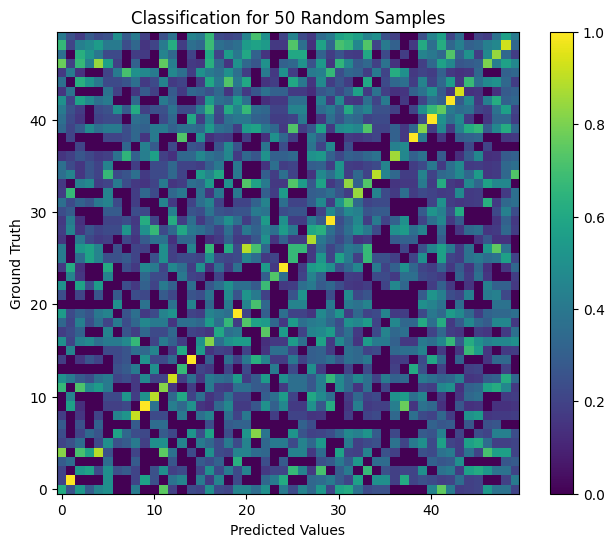

In [28]:
from src.classification import comparison_print
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib import pyplot as plt
import numpy as np


comparison_print("Miss Dior Cherie L'Eau Dior", df, onevsrest) # Predict the accords of a fragrance using our model, onevsrest
samples = 50

y_test_2 = y_test.values

fig, ax = plt.subplots(figsize=(8,6))
randIndices = np.random.choice(len(y_test_2), samples, replace= False)
cos_sim_sample = cosine_similarity(y_test_2[randIndices], y_pred[randIndices])

im = ax.imshow(cos_sim_sample, cmap= 'viridis', interpolation= 'nearest', origin='lower')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Ground Truth')
ax.set_title("Classification for 50 Random Samples")
plt.colorbar(im, ax=ax)

plt.show()